In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [30]:
from google.colab import files
uploaded = files.upload()


Saving house_price_regression_dataset.csv to house_price_regression_dataset (1).csv


In [31]:
df = pd.read_csv("house_price_regression_dataset.csv")


In [32]:
df.head()


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [33]:
df.shape


(1000, 8)

In [34]:
df.columns


Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

In [35]:
# A single feature model is used to keep the mathematical behaviour
# of the normal equation easy to interpret.

x = df["Square_Footage"].values   # feature (x)
y = df["House_Price"].values     # target (y)


In [36]:
x.shape


(1000,)

In [37]:
y.shape


(1000,)

In [38]:
# Create a column of ones for the intercept (b)
ones = np.ones(len(x))

# Combine x and the ones column to form the design matrix X
X = np.column_stack((x, ones))


In [39]:
X.shape



(1000, 2)

In [40]:
# Train / Test Split (used ONLY for evaluation purposes)
# The regression model itself is implemented from scratch

from sklearn.model_selection import train_test_split
import numpy as np

# Split the dataset into 80% training and 20% test data
# random_state is fixed to make the results reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit linear regression using the normal equation on TRAIN data only
beta = np.linalg.solve(X_train.T @ X_train, X_train.T @ y_train)

# Generate predictions on the TEST data
y_hat_test = X_test @ beta

# Compute Root Mean Squared Error (RMSE) on unseen test data
rmse_test = np.sqrt(np.mean((y_test - y_hat_test) ** 2))

print("RMSE_test:",rmse_test)


RMSE_test: 32885.947556117295


In [41]:
# The normal equation is solved using np.linalg.solve instead of an explicit inverse
# to improve numerical stability as the number of features increases.

beta = np.linalg.solve(X.T @ X, X.T @ y)

a = beta[0]  # slope
b = beta[1]  # intercept

a, b


(np.float64(200.19852990736263), np.float64(55217.673177152734))

In [42]:
# Predicted values from the fitted linear model.

y_hat = a * x + b


In [43]:
# Root Mean Squared Error (RMSE)
# RMSE is used as it measures prediction error in the same units as House_Price.

rmse = np.sqrt(np.mean((y - y_hat) ** 2))
rmse

# Mean house price
# The mean house price is used to interpret RMSE as a relative error.

mean_price = np.mean(y)
mean_price

# Relative error (%)
relative_error = (rmse / mean_price) * 100
relative_error

print("RMSE:",rmse)
print("Mean price:",mean_price)
print("Relative error (%):",relative_error)

RMSE: 33431.903580265505
Mean price: 618861.018646
Relative error (%): 5.402166653412885


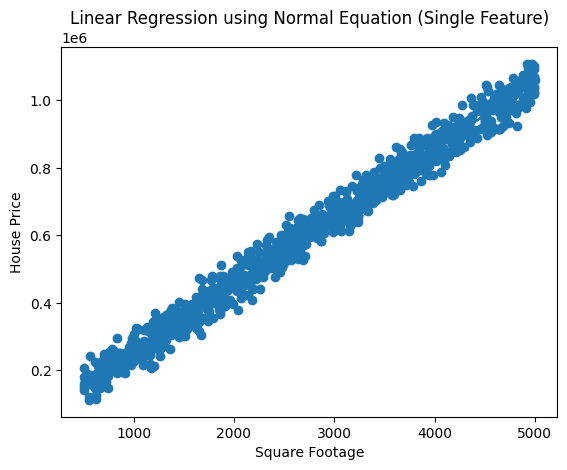

In [44]:
plt.scatter(x, y)
plt.plot(x, y_hat)
plt.xlabel("Square Footage")
plt.ylabel("House Price")
plt.title("Linear Regression using Normal Equation (Single Feature)")
plt.show()


In [45]:
# Synthetic data is generated to analyse how the computational cost
# of the normal equation scales with sample size and number of features,
# while keeping the data distribution controlled.

import time

def make_synthetic_data(n, p, seed=0):
    np.random.seed(seed)
    X = np.random.randn(n, p)
    true_beta = np.random.randn(p)
    y = X @ true_beta
    return X, y

def time_normal_equation(X, y):
    start = time.perf_counter()
    _ = np.linalg.solve(X.T @ X, X.T @ y)
    end = time.perf_counter()
    return end - start


In [46]:
# Fix number of features
p = 10

# Different sample sizes
n_values = [200, 500, 1000, 2000, 5000]

times_n = []

# Measuring runtime while increasing the number of samples (fixed number of features).

for n in n_values:
    X_synth, y_synth = make_synthetic_data(n, p)
    time_taken = time_normal_equation(X_synth, y_synth)
    times_n.append(time_taken)

print(times_n)


[0.00013446799999883297, 8.635899996534135e-05, 0.00012121299999989787, 0.00010637200000473968, 0.0002911500000095657]


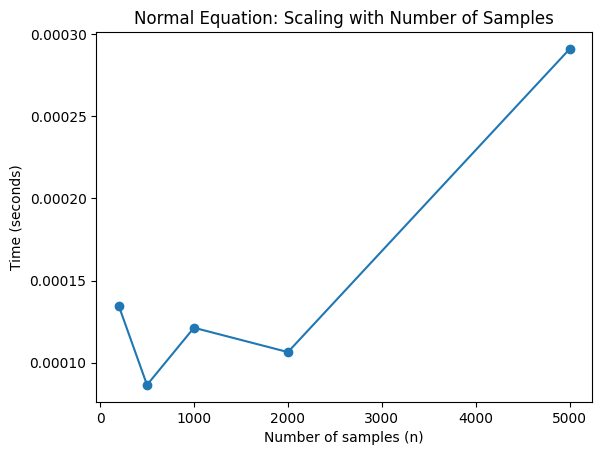

In [47]:
plt.plot(n_values, times_n, marker="o")
plt.xlabel("Number of samples (n)")
plt.ylabel("Time (seconds)")
plt.title("Normal Equation: Scaling with Number of Samples")
plt.show()


In [48]:
# Fix number of samples
n = 2000

# Different feature sizes
p_values = [2, 5, 10, 20, 30, 50]

times_p = []

# Measuring runtime while increasing the number of features (fixed sample size).

for p in p_values:
    X_synth, y_synth = make_synthetic_data(n, p)
    time_taken = time_normal_equation(X_synth, y_synth)
    times_p.append(time_taken)

print(times_p)


[0.00018337000000201442, 0.00012106399998401685, 0.0001765000000091277, 0.0002652969999985544, 0.00035886499995285703, 0.0006929919999834055]


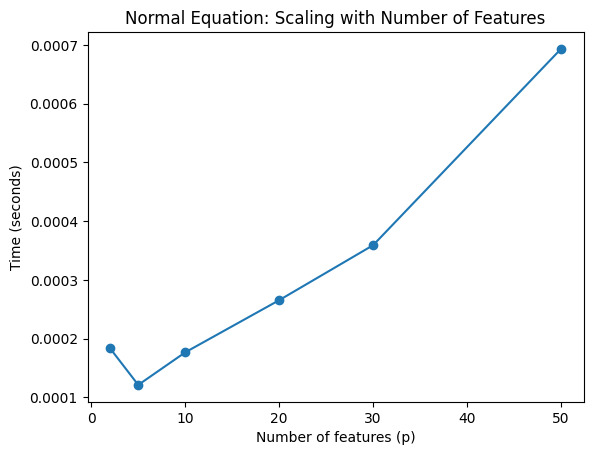

In [49]:
plt.plot(p_values, times_p, marker="o")
plt.xlabel("Number of features (p)")
plt.ylabel("Time (seconds)")
plt.title("Normal Equation: Scaling with Number of Features")
plt.show()
